# Air Plane Crashes Analysis- EDA

We are building an EDA project to analyze historical airline accidents from 1908 to present.

<img src='https://dashinjurylaw.com/wp-content/uploads/2020/06/fire-4733716_1920.jpg' width='750'>

In [2]:
#Libraries
import time
import nltk
import string
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from scipy import stats
from sklearn import metrics
import plotly.express as px
import statsmodels.api as sm
from itertools import product
from collections import Counter
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import plotly.graph_objects as go
from statsmodels.formula.api import ols
from ydata_profiling import ProfileReport
from plotly.subplots import make_subplots
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings 
warnings.filterwarnings("ignore")
%matplotlib inline

# EDA

In [3]:
df=pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908.csv')

In [4]:
df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [5]:
df.tail()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...
5267,06/08/2009,NaN,"State of Arunachal Pradesh, India",Military - Indian Air Force,NaN,Mechuka for Jorhat,Antonov An-32,NaN,NaN,13.0,13.0,0.0,The military transport went missing while en r...


In [6]:
df.shape

(5268, 13)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5268 entries, 0 to 5267
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          5268 non-null   object 
 1   Time          3049 non-null   object 
 2   Location      5248 non-null   object 
 3   Operator      5250 non-null   object 
 4   Flight #      1069 non-null   object 
 5   Route         3561 non-null   object 
 6   Type          5241 non-null   object 
 7   Registration  4933 non-null   object 
 8   cn/In         4040 non-null   object 
 9   Aboard        5246 non-null   float64
 10  Fatalities    5256 non-null   float64
 11  Ground        5246 non-null   float64
 12  Summary       4878 non-null   object 
dtypes: float64(3), object(10)
memory usage: 535.2+ KB


In [8]:
df.isnull().sum()

Date               0
Time            2219
Location          20
Operator          18
Flight #        4199
Route           1707
Type              27
Registration     335
cn/In           1228
Aboard            22
Fatalities        12
Ground            22
Summary          390
dtype: int64

In [9]:
df.describe()

,Aboard,Fatalities,Ground
count,5246.000000,5256.000000,5246.000000
mean,27.554518,20.068303,1.608845
std,43.076711,33.199952,53.987827
min,0.000000,0.000000,0.000000
25%,5.000000,3.000000,0.000000
50%,13.000000,9.000000,0.000000
75%,30.000000,23.000000,0.000000
max,644.000000,583.000000,2750.000000


In [10]:
df.corr(numeric_only=True)

,Aboard,Fatalities,Ground
Aboard,1.000000,0.757172,0.023241
Fatalities,0.757172,1.000000,0.035170
Ground,0.023241,0.035170,1.000000


In [12]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = pd.DatetimeIndex(df['Date']).month
df['Year'] = pd.DatetimeIndex(df['Date']).year

In [13]:
# split the company name
df['Manufacture'] = df['Type'].apply(lambda x: x.split(' ')[0] if type(x) == str else 'Others')

In [14]:
# handle null values
warnings.filterwarnings("ignore")
df['Location'].fillna('', inplace=True)
df['Flight #'].fillna('Unavailable', inplace=True)
df['Route'].fillna('Unavailable', inplace=True)
df['Place'] = df['Location'].apply(lambda x: x.split(',')[0] if ',' in x else x)
df['Time'].fillna('Unknown',inplace=True)
df['Time'].isnull().any()
df['Operator'].fillna(df['Operator'].mode()[0],inplace = True)
df['cn/In'].fillna('Unknown', inplace=True)
df['Registration'].fillna(df['Registration'].mode()[0],inplace=True)
df['Type'].fillna(df['Type'].mode()[0],inplace=True)
df['Aboard'].fillna(df['Aboard'].mean(),inplace=True)
df['Fatalities'].fillna(df['Fatalities'].mean(),inplace=True)
df['Ground'].fillna(df['Ground'].mean(),inplace=True)
df['Summary'].fillna('Unknown',inplace=True)
warnings.resetwarnings()

In [15]:
df.isnull().sum()

Date            0
Time            0
Location        0
Operator        0
Flight #        0
Route           0
Type            0
Registration    0
cn/In           0
Aboard          0
Fatalities      0
Ground          0
Summary         0
Month           0
Year            0
Manufacture     0
Place           0
dtype: int64

In [16]:
accidents_by_location = df['Location'].value_counts().reset_index()
accidents_by_location.columns=['Location','Accident Count']
top_20_locations = accidents_by_location.head(20)
print(top_20_locations)

                     Location  Accident Count
0                                          20
1           Sao Paulo, Brazil              15
2              Moscow, Russia              15
3      Rio de Janeiro, Brazil              14
4            Bogota, Colombia              13
5           Anchorage, Alaska              13
6         Manila, Philippines              13
7          New York, New York              12
8                Cairo, Egypt              12
9           Chicago, Illinois              11
10        Near Moscow, Russia               9
11               Tehran, Iran               9
12               AtlantiOcean               9
13              Paris, France               8
14           Denver, Colorado               8
15                Rome, Italy               8
16             Ankara, Turkey               8
17     Amsterdam, Netherlands               8
18             Kunming, China               7
19  Guatemala City, Guatemala               7


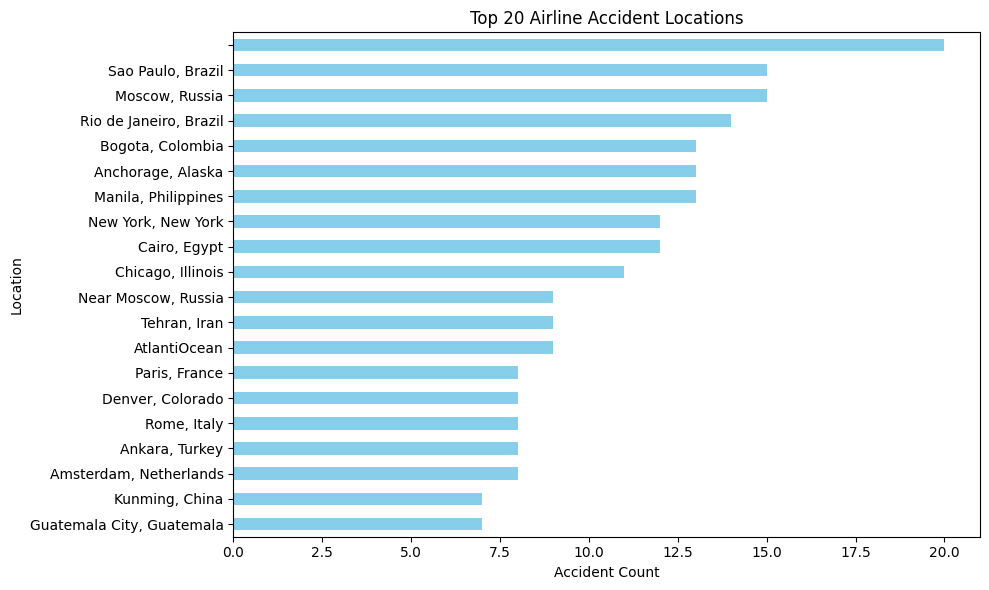

In [17]:
# Top 20 locations plot directly from Pandas
df['Location'].value_counts().head(20).plot(
    kind='barh', figsize=(10, 6), color='skyblue'
).invert_yaxis()

plt.title('Top 20 Airline Accident Locations')
plt.xlabel('Accident Count')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

In [18]:
accident_types_by_location = df.groupby('Location')['Type'].apply(lambda x: x.value_counts().idxmax()).reset_index()
accident_types_by_location.columns = ['Location','Most Common Accident Type']
accident_types_by_location = accident_types_by_location.head(10)
accident_types_by_location

,Location,Most Common Accident Type
0,,Junkers JU-53/3m
1,"1,200 miles off Dakar, AtlantiOcean",Latecoere 631 (flying boat)
2,"100 miles SW of Kuujjuaq, Quebec, Canada",Cessna 180K
3,"110 miles SW of Sochi, Russia",Tupolev Tu-154M
4,"200 miles NE of Derby, Australia",Robertson R44 helicopter
5,"25 nm off Agrigento, Italy",Vickers Valetta Mk1 / Avero Lancaster
6,"300 nm NW of San Francisco, California",Boeing B-747-SP-09
7,"900 miles E of Honolulu, Hawaii, PacifiOcean",Boeing - 377-10-29 Stratocruiser
8,"950 nm S of Shemya, Alaska",McDonnell Douglas MD-11
9,"Abakan, Siberia, Russia",Ilyushin IL-76MD


In [22]:
accidents_byy_location = df['Location'].value_counts().reset_index()
accidents_byy_location.columns=['Location','Accident Count']
top_locations = accidents_byy_location.head(5268)

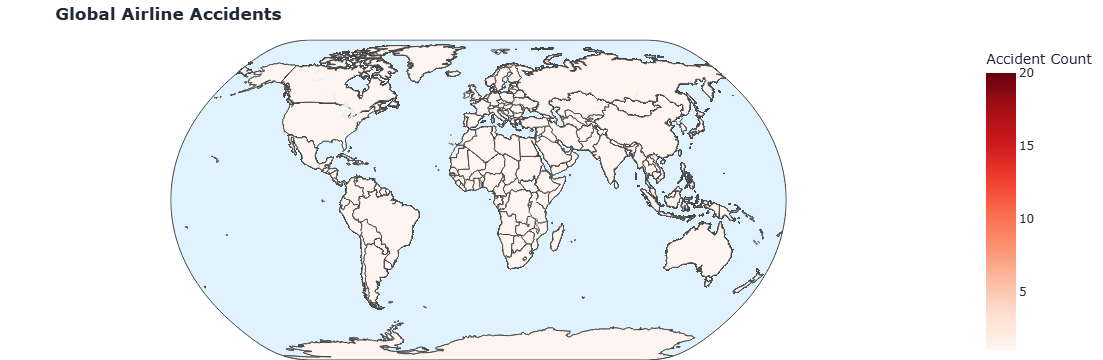

In [28]:
import plotly.express as px

fig = px.choropleth(
    top_locations,
    locations='Location',
    locationmode='country names',
    color='Accident Count',
    color_continuous_scale='Reds',
    projection='natural earth',
    template='plotly_white',
    title='<b>Global Airline Accidents</b>'
)

fig.update_geos(
    showocean=True, 
    oceancolor='#e0f2fe',
    landcolor='#f3f4f6',
    showlakes=True,
    lakecolor='#e0f2fe'
)

fig.update_layout(
    margin=dict(l=0, r=0, t=40, b=0),
    paper_bgcolor='#ffffff',
    font=dict(color='#1f2937')
)

fig.show()

In [29]:
accidents_byyy_location = df['Location'].value_counts().reset_index()
accidents_byyy_location.columns=['Location','Accident Count']
top = accidents_byyy_location.head(30)

In [30]:
top.head()

,Location,Accident Count
0,,20
1,"Sao Paulo, Brazil",15
2,"Moscow, Russia",15
3,"Rio de Janeiro, Brazil",14
4,"Bogota, Colombia",13


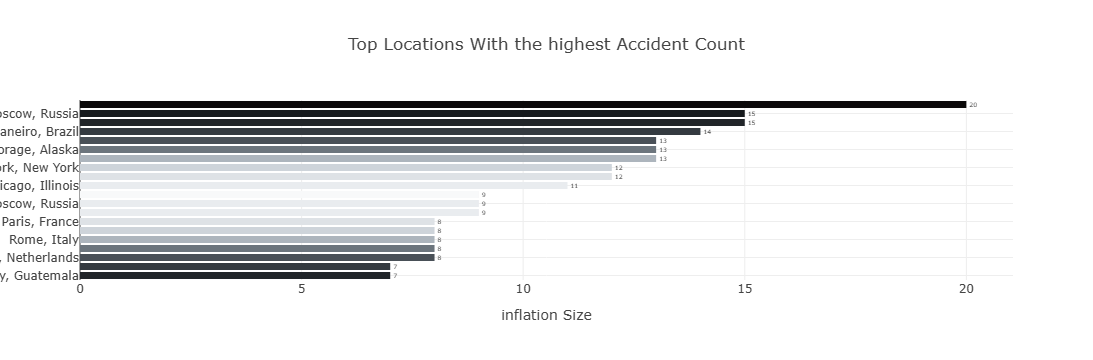

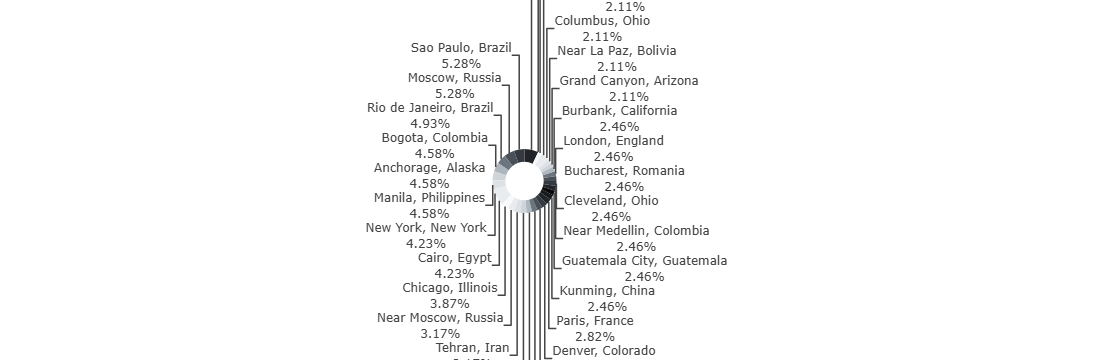

In [31]:
warnings.filterwarnings("ignore")
data = top_20_locations[['Location', 'Accident Count']].sort_values('Accident Count', ascending=False)[:20]
colors = ['#212529', '#343a40', '#495057', '#6C757D', '#ADB5BD', '#CED4DA', '#DEE2E6', '#E9ECEF', '#E9ECEF', '#F8F9FA', '#E9ECEF', '#DEE2E6','#CED4DA','#ADB5BD','#6C757D','#495057','#343a40','#212529','#161a1d','#0b090a']
fig = go.Figure(go.Bar(
            x=data['Accident Count'][::-1],
            y=data['Location'][::-1],
            marker=dict(color=colors),
            text=data['Accident Count'].apply(lambda x:str(int(x)))[::-1], 
            textposition='outside',
            orientation='h'))
fig.update_layout(
    title='Top Locations With the highest Accident Count',
    xaxis_title="inflation Size",
    template='gridon',
    plot_bgcolor='rgba(0, 0, 0, 0)',
    paper_bgcolor='rgba(0, 0, 0, 0)',)
fig.show()
df_sorted = top.sort_values('Accident Count', ascending=False)
top_n = 30
top_countries = df_sorted.head(top_n)
other_inflation = df_sorted.iloc[top_n:]['Accident Count'].sum()
new_df = pd.concat([top_countries, pd.DataFrame({'Location': ['Others'], 'Accident Count': [other_inflation]})])
colors = ['#212529', '#343a40', '#495057', '#6C757D', '#ADB5BD', '#CED4DA', '#DEE2E6', '#E9ECEF', '#E9ECEF', '#F8F9FA', '#E9ECEF', '#DEE2E6','#CED4DA','#ADB5BD','#6C757D','#495057','#343a40','#212529','#161a1d','#0b090a','#212529', '#343a40', '#495057', '#6C757D', '#ADB5BD', '#CED4DA', '#DEE2E6', '#E9ECEF', '#E9ECEF', '#F8F9FA']
fig = go.Figure(data=[go.Pie(labels=new_df['Location'],
                             values=new_df['Accident Count'],
                             textinfo="label+percent",
                             pull=[0, 0, 0],
                             showlegend=False,
                             marker_colors=colors,
                            )])
fig.update_traces(
    hole=0.6)
fig.update_layout(
    template='gridon',
    plot_bgcolor='rgba(0, 0, 0, 0)',
    paper_bgcolor='rgba(0, 0, 0, 0)',
)
fig.show()

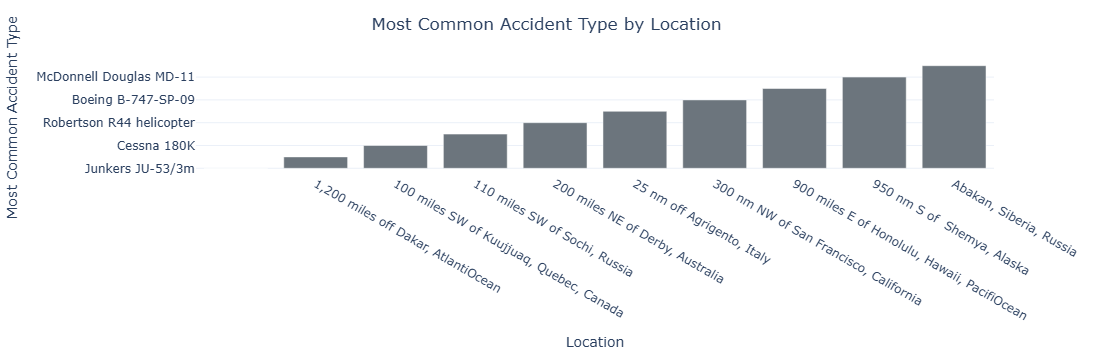

In [33]:
warnings.filterwarnings("ignore", category=DeprecationWarning)
fig = px.bar(accident_types_by_location, x='Location', y='Most Common Accident Type',template = 'plotly_white')
fig.update_traces(marker_color='#6c757d')
fig.update_layout(title='Most Common Accident Type by Location',title_x = 0.5)
fig.show()

In [34]:
operator_counts = df['Operator'].value_counts().reset_index().head(25)
operator_counts.columns = ['Operator','Accident Count']
operator_counts

,Operator,Accident Count
0,Aeroflot,197
1,Military - U.S. Air Force,176
2,Air France,70
3,Deutsche Lufthansa,65
4,China National Aviation Corporation,44
5,Air Taxi,44
6,United Air Lines,44
7,Military - U.S. Army Air Forces,43
8,Pan American World Airways,41
9,Military - U.S. Navy,36


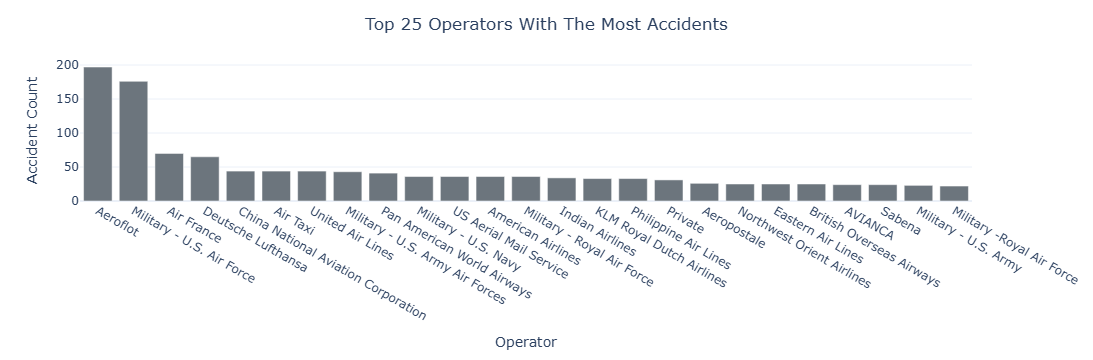

None


In [35]:
warnings.filterwarnings("ignore", category=DeprecationWarning)
operator_counts['Accident Count'] = operator_counts['Accident Count'].astype('int')
fig = px.bar(operator_counts,x='Operator', y='Accident Count',template = 'plotly_white')
fig.update_traces(marker_color='#6c757d')
fig.update_layout(title = 'Top 25 Operators With The Most Accidents',title_x=0.5)
print(fig.show())

In [36]:
aircraft = df.groupby(['Type','Registration','Manufacture']).size().reset_index()
aircraft.columns = ['Aircraft Type','Registration','Manufacture','Accidents']
aircraft = aircraft.sort_values(by='Accidents',ascending=False)
aircraft.reset_index(inplace=True)
aircraft=aircraft.head(25)
aircraft

,index,Aircraft Type,Registration,Manufacture,Accidents
0,2251,Douglas DC-3,49,Others,17
1,1902,Douglas C-47,49,Douglas,16
2,228,Antonov AN-26,49,Antonov,13
3,2250,Douglas DC-3,49,Douglas,12
4,1021,Breguet 14,49,Breguet,9
5,135,Antonov AN-12,49,Antonov,9
6,4150,Mil Mi-8 (helicopter),49,Mil,8
7,1669,Curtiss C-46,49,Curtiss,6
8,2830,Douglas M-4,49,Douglas,5
9,4354,Pitcairn PA-6 Mailwing,49,Pitcairn,4


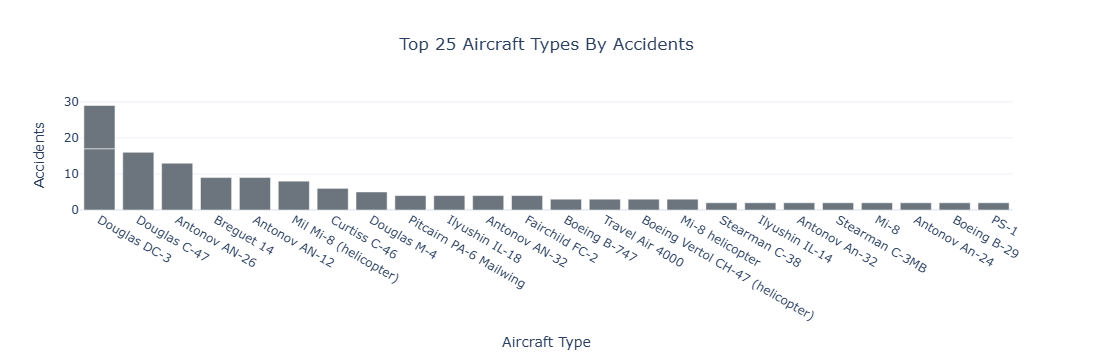

In [37]:
warnings.filterwarnings("ignore", category=DeprecationWarning)
fig = px.bar(aircraft,x='Aircraft Type',y='Accidents',title='Top 25 Aircraft Types By Accidents',template = 'plotly_white')
fig.update_traces(marker_color='#6c757d')
fig.update_layout(title_x = 0.5)
fig.show()

In [38]:
fatality = df['Aboard'].corr(df['Fatalities'])
ground = df['Aboard'].corr(df['Ground'])
print('Correlation betwwen Aboard and Fatalities:', fatality)
print('Correlation between Aboard and Aboard:', ground)

Correlation betwwen Aboard and Fatalities: 0.756713509843817
Correlation between Aboard and Aboard: 0.023236441300522503


      Aboard  Fatalities    Ground
0        2.0         1.0  0.000000
1        5.0         5.0  0.000000
2        1.0         1.0  0.000000
3       20.0        14.0  0.000000
4       30.0        30.0  0.000000
...      ...         ...       ...
5263   112.0        98.0  2.000000
5264     4.0         4.0  1.608845
5265   228.0       228.0  0.000000
5266     1.0         1.0  0.000000
5267    13.0        13.0  0.000000

[5268 rows x 3 columns]


<function matplotlib.pyplot.show(close=None, block=None)>

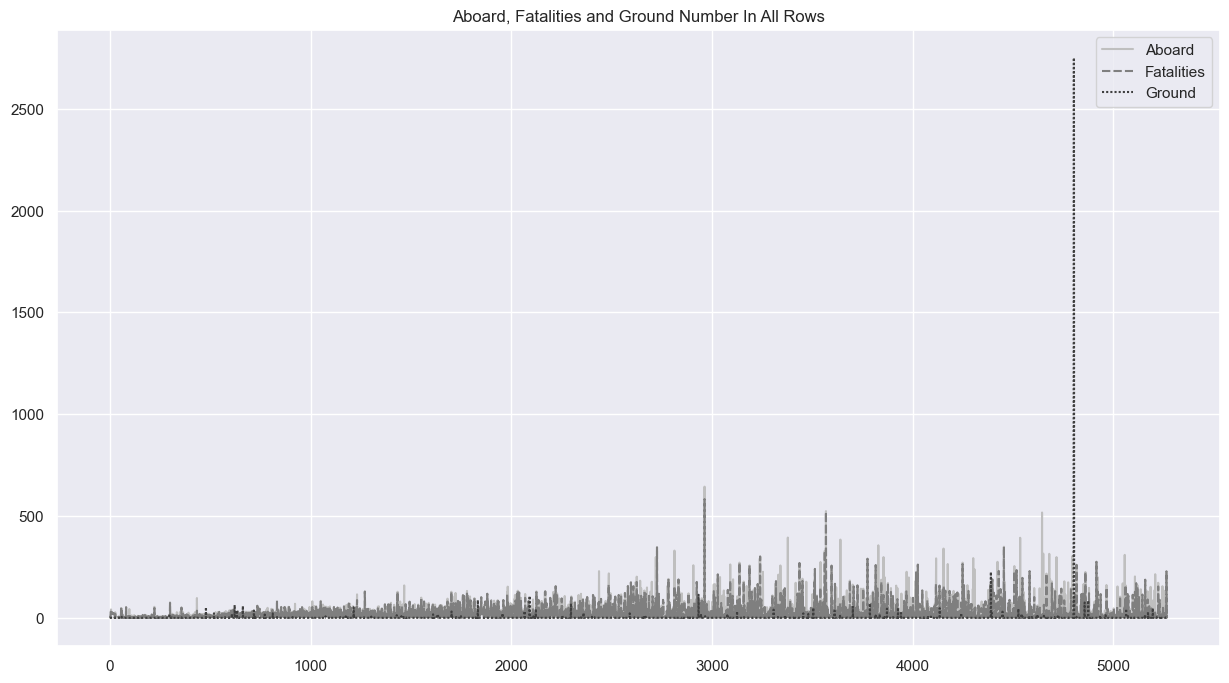

In [39]:
top10=df.iloc[:5269 , :]
top10u= top10.loc[:,['Aboard', 'Fatalities', 'Ground']]
print(top10u)
plt.figure(figsize=(15,8))
sns.lineplot(data=top10u,palette="binary")
plt.title('Aboard, Fatalities and Ground Number In All Rows')
plt.show

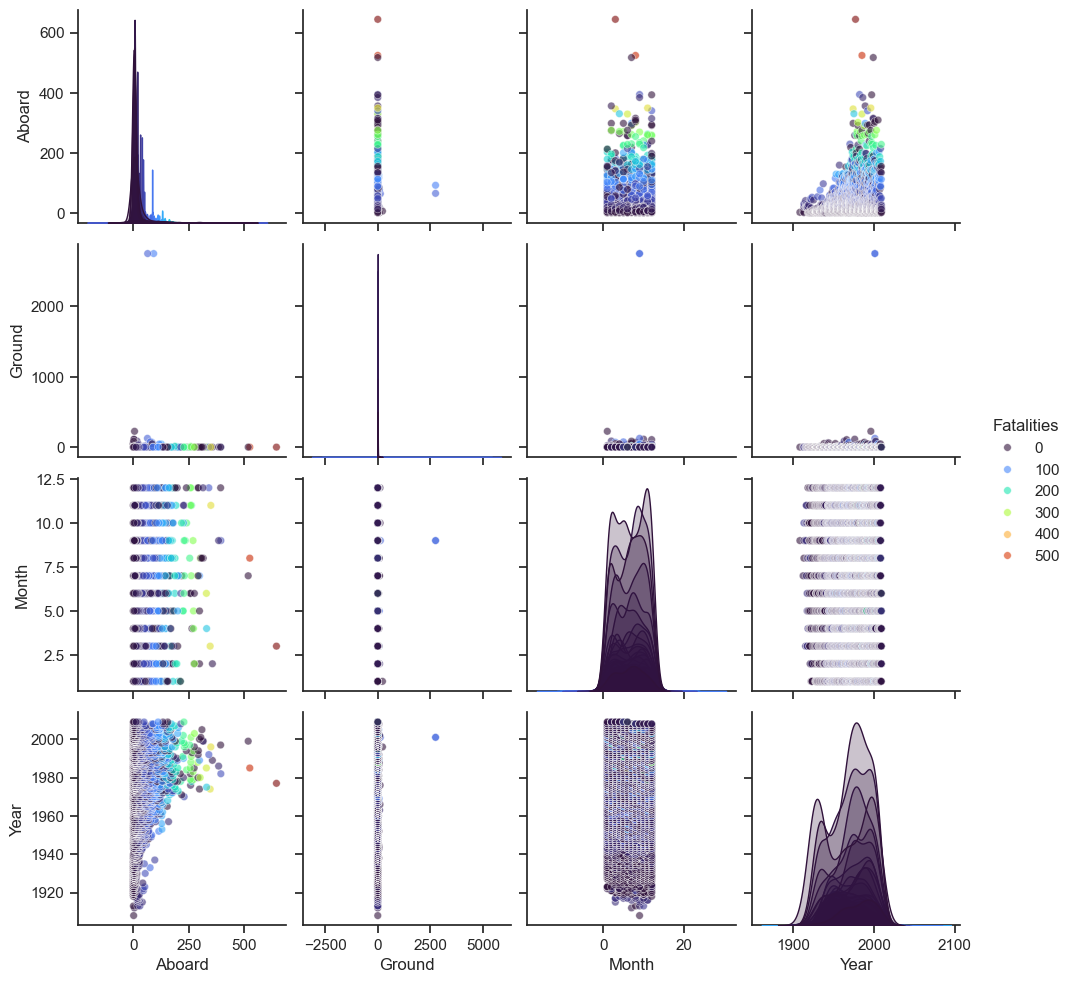

In [46]:
warnings.filterwarnings("ignore")
sns.set_theme(style="ticks")

# Continuous numerical hue works best with vibrant continuous palettes like 'viridis', 'plasma', or 'turbo'
sns.pairplot(
    data=df, 
    diag_kind='kde', 
    hue="Fatalities", 
    palette="turbo",  # High-contrast, bright rainbow gradient
    plot_kws={'alpha': 0.6, 's': 30}  # Transparency & marker size for clarity
)

plt.show()

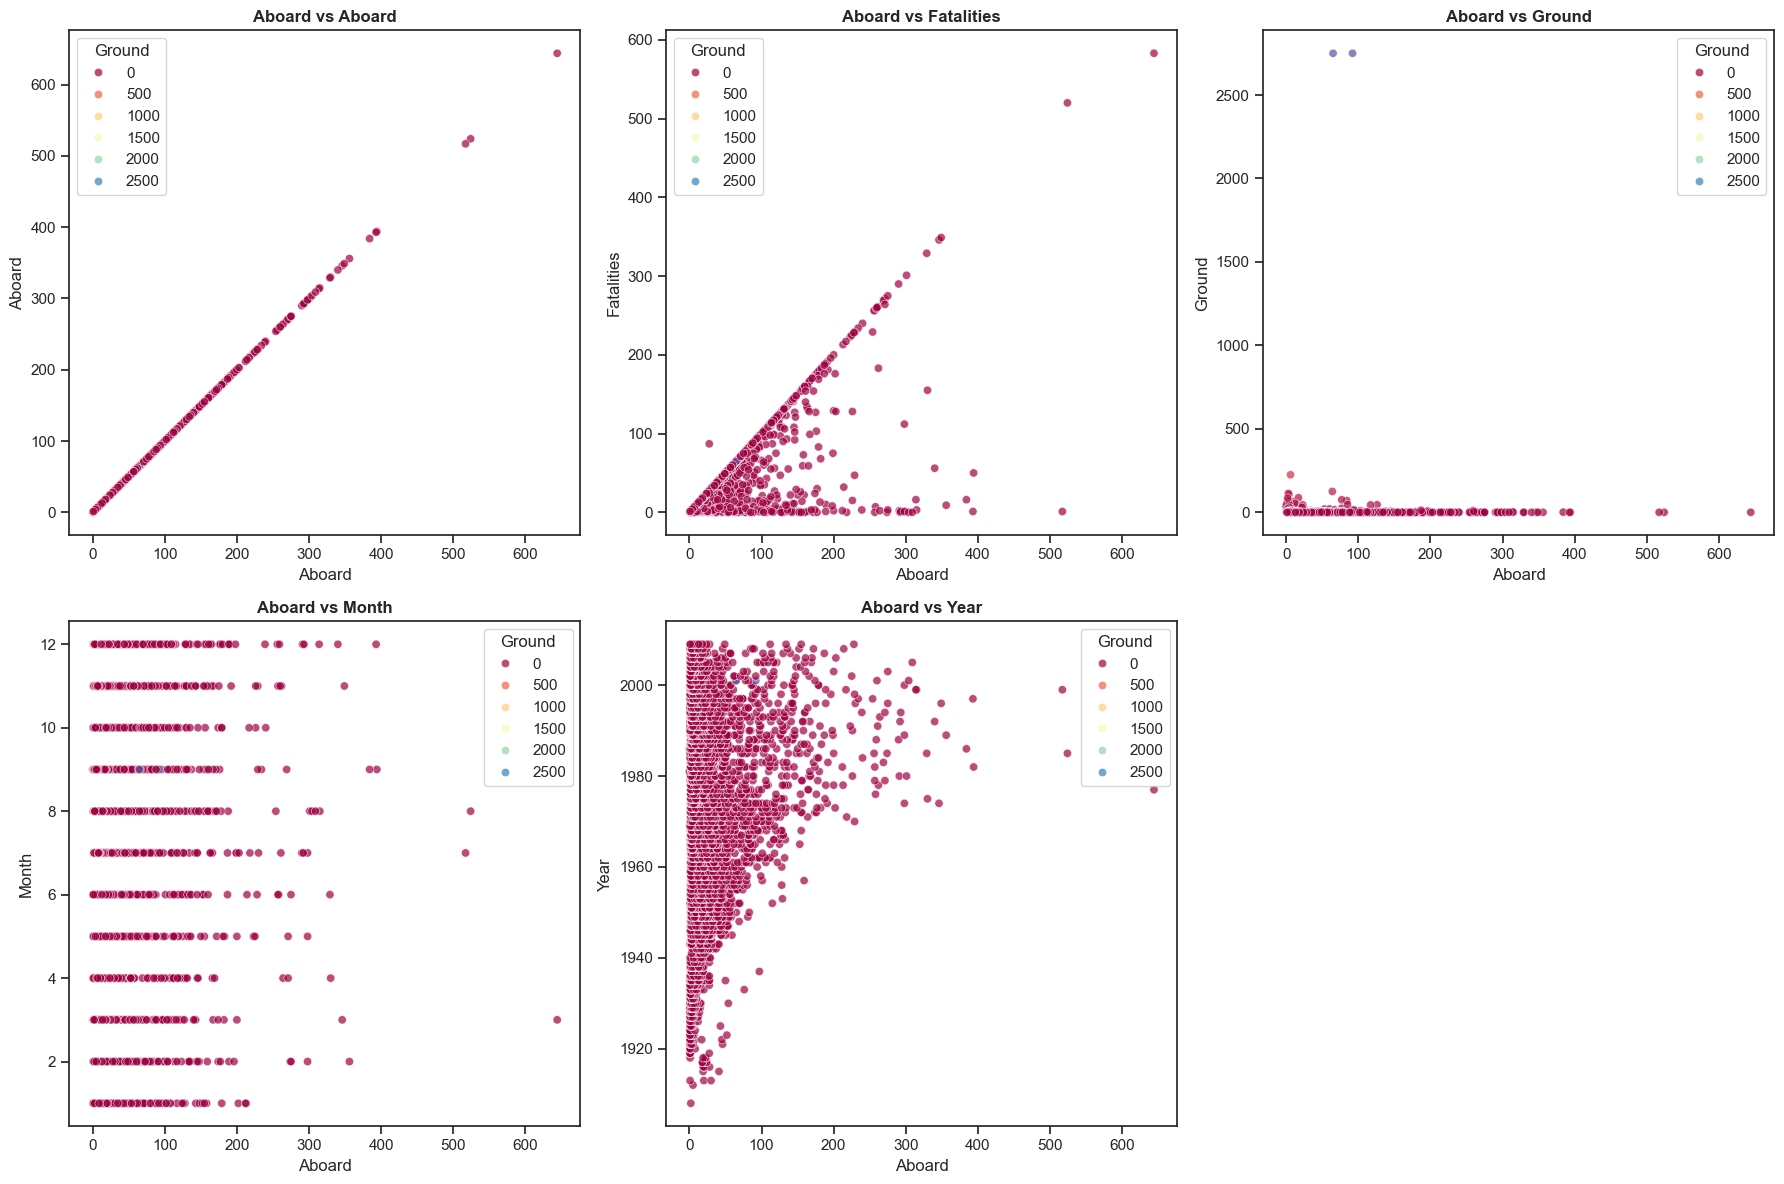

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

ff = ['Aboard', 'Fatalities', 'Ground', 'Month', 'Year']
fig = plt.figure(figsize=(18, 12))

for i, col in enumerate(ff):
    ax = fig.add_subplot(2, 3, i + 1)
    # Vibrant palette + opacity for layered points
    sns.scatterplot(
        x='Aboard', 
        y=col, 
        hue='Ground', 
        data=df, 
        palette='Spectral', 
        alpha=0.7,
        ax=ax
    )
    ax.set_title(f'Aboard vs {col}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

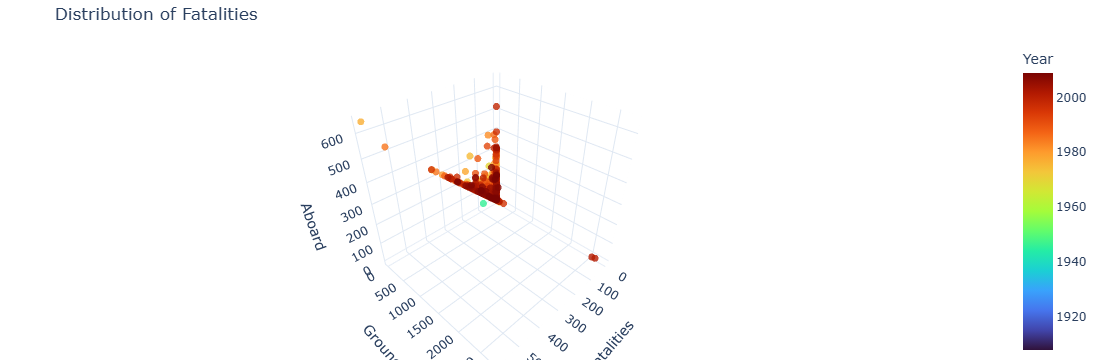

In [44]:
import plotly.express as px
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

fig = px.scatter_3d(
    df, 
    x='Fatalities', 
    y='Ground', 
    z='Aboard', 
    color='Year',
    color_continuous_scale='Turbo',
    title='Distribution of Fatalities',
    template='plotly_white'
)

fig.update_traces(
    marker=dict(size=4, opacity=0.8)
)

fig.update_layout(
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.show()

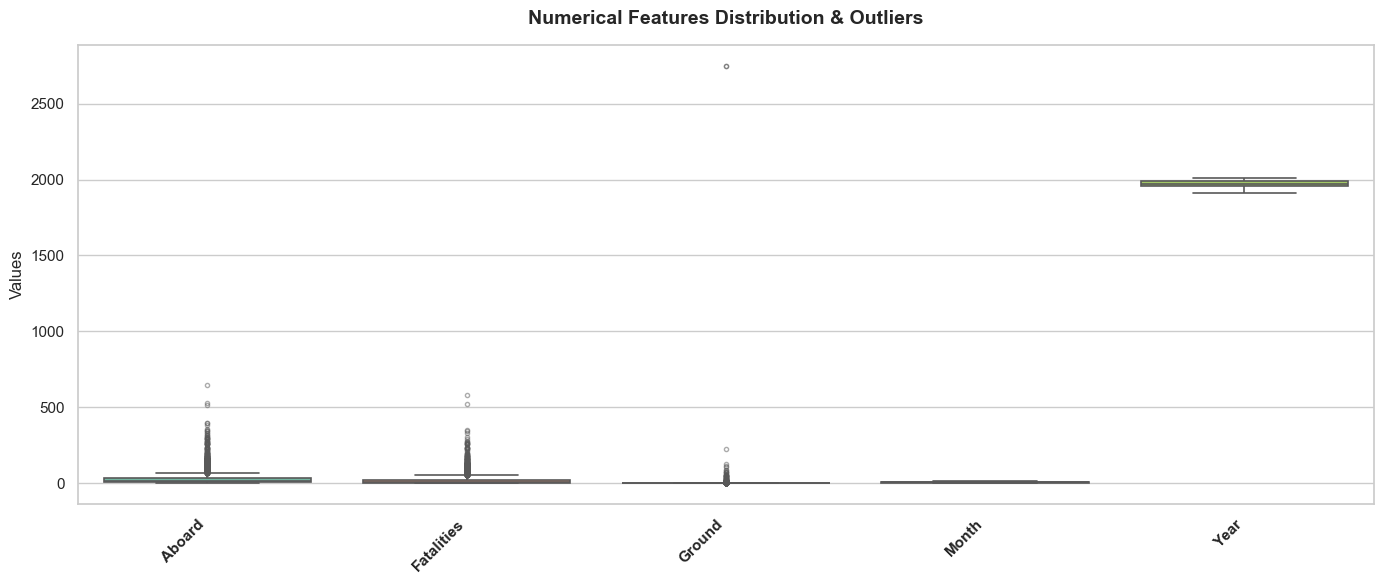

In [48]:
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Modern, clean boxplot
ax = sns.boxplot(
    data=df.select_dtypes(include=['number']),  # Automatically filters numerical columns
    palette='Set2',
    linewidth=1.2,
    fliersize=3,                                # Smaller outlier dots for cleaner look
    flierprops=dict(marker='o', color='gray', alpha=0.5)
)

plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')
plt.title('Numerical Features Distribution & Outliers', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Values', fontsize=12)
plt.tight_layout()
plt.show()

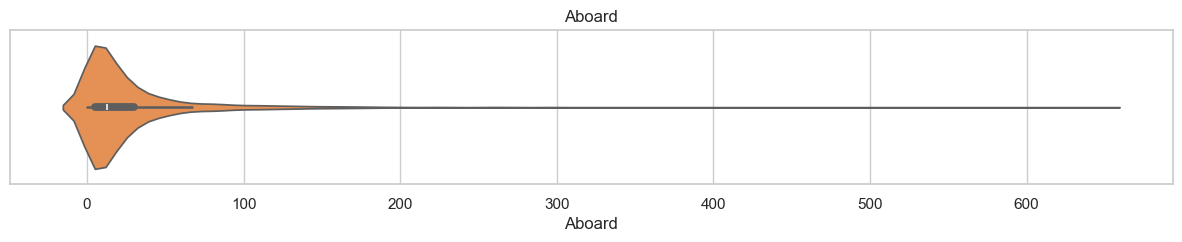

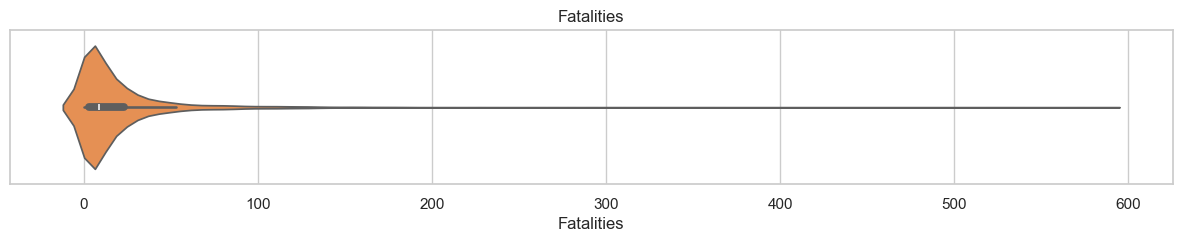

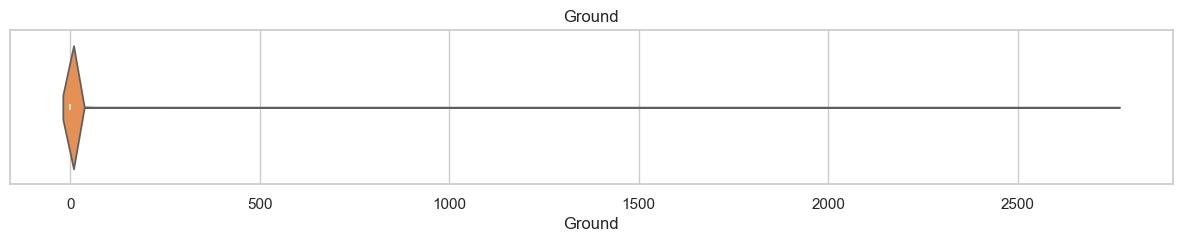

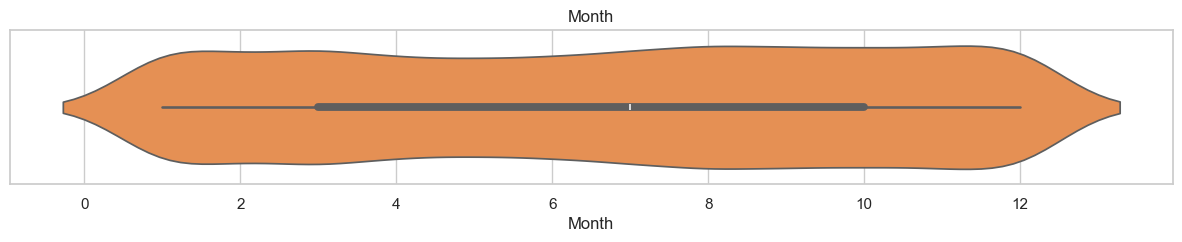

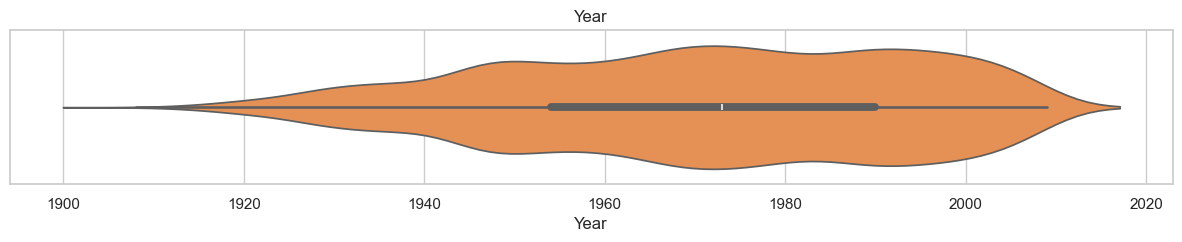

In [49]:
palette ="Oranges"
for column in ff:
    plt.figure(figsize=(15,2))
    sns.violinplot(x=df[column], palette=palette)
    plt.title(column)
    plt.show()


Aboard Statistics:
count: 5268.00, mean: 27.55, std: 42.99, min: 0.00, 25%: 5.00, 50%: 13.00, 75%: 30.00, max: 644.00


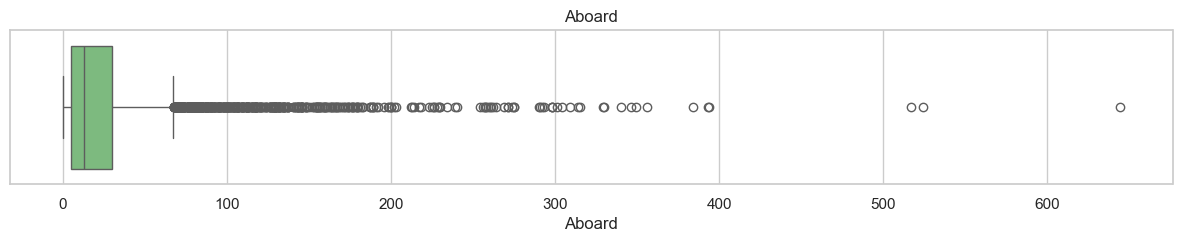


Fatalities Statistics:
count: 5268.00, mean: 20.07, std: 33.16, min: 0.00, 25%: 3.00, 50%: 9.00, 75%: 23.00, max: 583.00


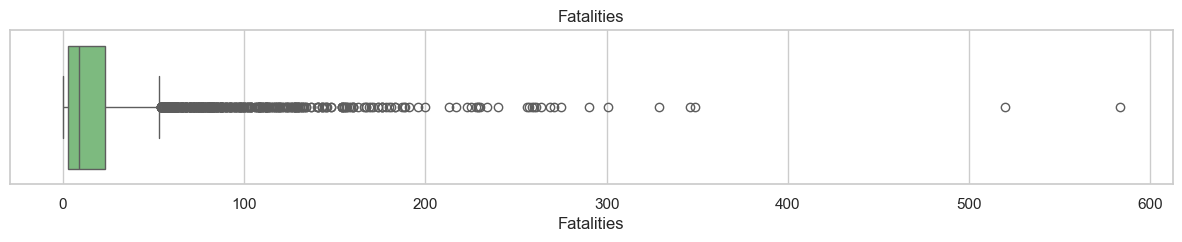


Ground Statistics:
count: 5268.00, mean: 1.61, std: 53.87, min: 0.00, 25%: 0.00, 50%: 0.00, 75%: 0.00, max: 2750.00


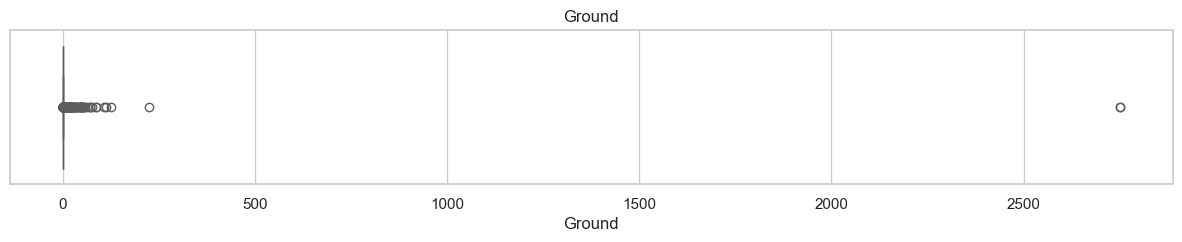


Month Statistics:
count: 5268.00, mean: 6.64, std: 3.55, min: 1.00, 25%: 3.00, 50%: 7.00, 75%: 10.00, max: 12.00


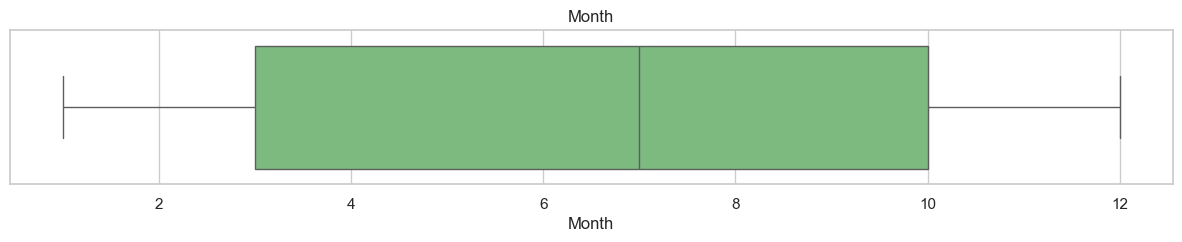


Year Statistics:
count: 5268.00, mean: 1971.30, std: 22.39, min: 1908.00, 25%: 1954.00, 50%: 1973.00, 75%: 1990.00, max: 2009.00


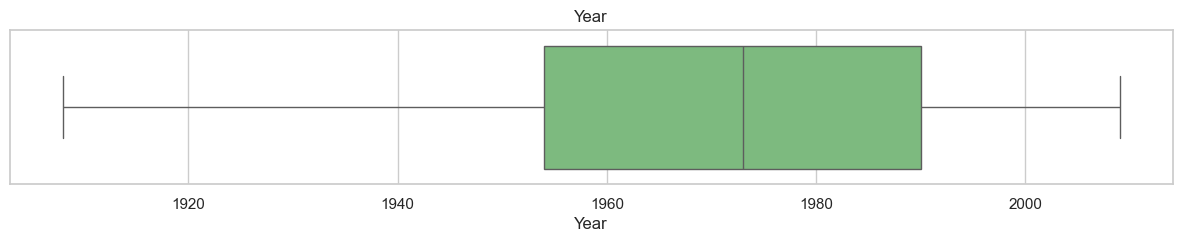

In [50]:
palette ="Greens"
for column in ff:
    plt.figure(figsize=(15,2))
    sns.boxplot(x=df[column], palette=palette)
    plt.title(column)
    stats = df[column].describe()
    stats_text = ", ".join([f"{key}: {value:.2f}" for key, value in stats.items()])
    print(f"\n{column} Statistics:\n{stats_text}")
    plt.show()

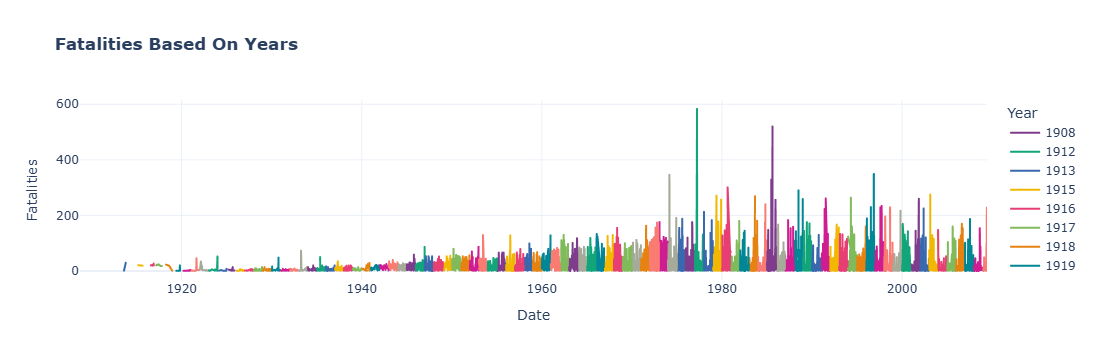

In [51]:
warnings.filterwarnings("ignore", category=DeprecationWarning)

fig = px.line(
    df, 
    x='Date', 
    y='Fatalities', 
    color='Year',                  
    color_discrete_sequence=px.colors.qualitative.Bold, 
    title='<b>Fatalities Based On Years</b>', 
    template='plotly_white'
)

fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Fatalities',
    hovermode='x unified'
)

fig.show()

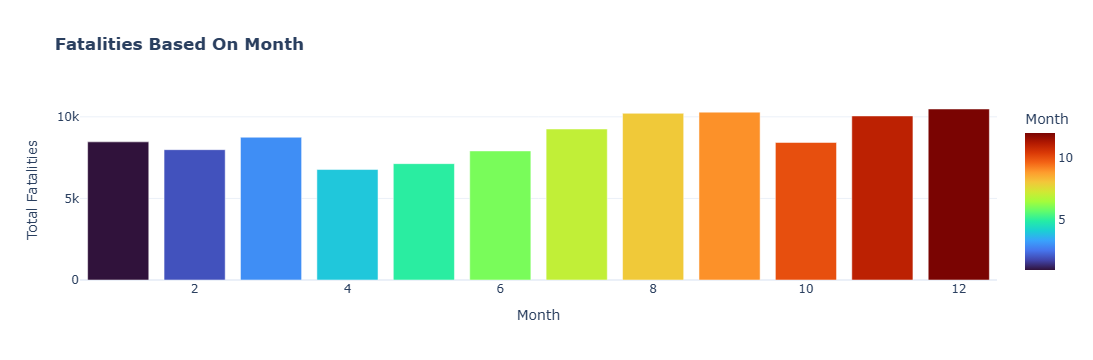

In [52]:
warnings.filterwarnings("ignore", category=DeprecationWarning)

fig = px.bar(
    df.groupby('Month')['Fatalities'].sum().reset_index(),
    x='Month',
    y='Fatalities',
    color='Month',
    color_continuous_scale='Turbo', 
    title='<b>Fatalities Based On Month</b>',
    template='plotly_white'
)

fig.update_layout(xaxis_title='Month', yaxis_title='Total Fatalities', showlegend=False)
fig.show()

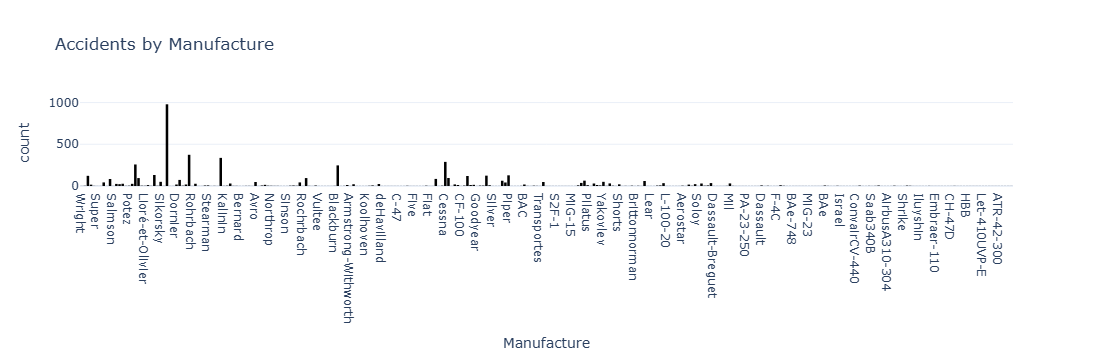

In [54]:
warnings.filterwarnings("ignore", category=DeprecationWarning)
fig = px.histogram(df, x = 'Manufacture', template = 'plotly_white', title='Accidents by Manufacture',color_discrete_sequence=px.colors.sequential.gray)
fig.show()

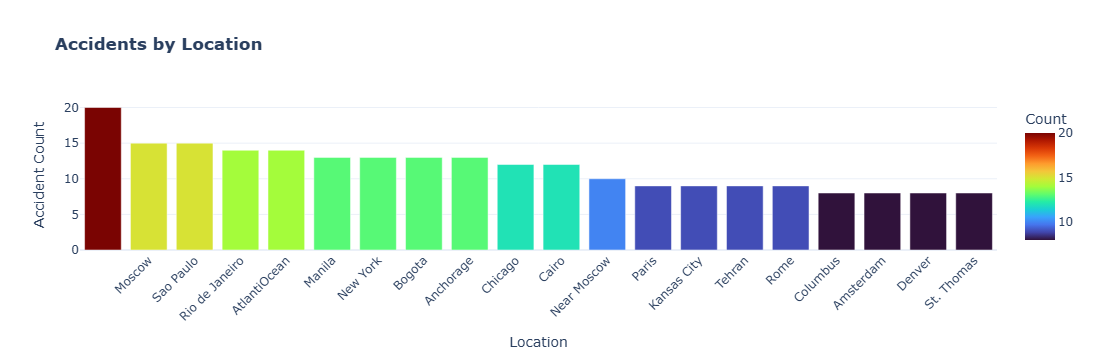

In [55]:
warnings.filterwarnings("ignore", category=DeprecationWarning)

location_counts = df['Place'].value_counts().reset_index()
location_counts.columns = ['Place', 'Count']

fig = px.bar(
    location_counts.head(20), 
    x='Place',
    y='Count',
    color='Count',
    color_continuous_scale='Turbo', 
    title='<b>Accidents by Location</b>',
    template='plotly_white'
)

fig.update_layout(
    xaxis_title='Location',
    yaxis_title='Accident Count',
    xaxis_tickangle=-45
)

fig.show()

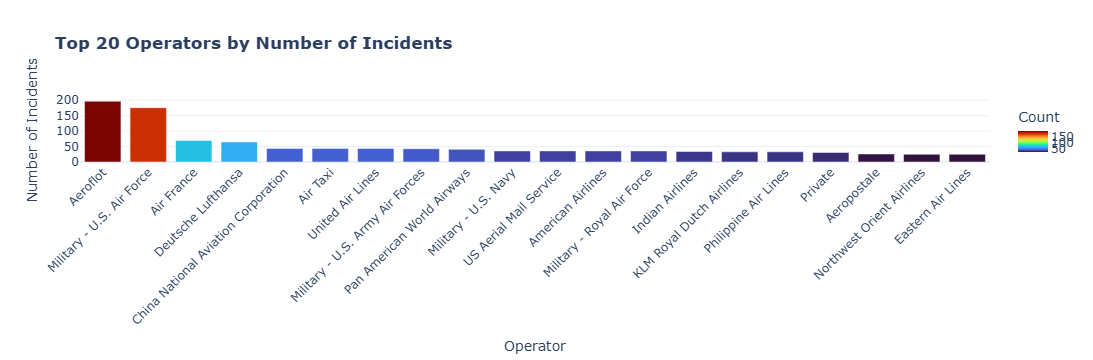

In [57]:
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Operatör bazlı kaza sayıları (İlk 20)
operator_counts = df['Operator'].value_counts().reset_index().head(20)
operator_counts.columns = ['Operator', 'Count']

fig = px.bar(
    operator_counts,
    x='Operator',
    y='Count',
    color='Count',
    color_continuous_scale='Turbo',  # Canlı ve yüksek kontrastlı renk skalası
    title='<b>Top 20 Operators by Number of Incidents</b>',
    template='plotly_white'
)

fig.update_layout(
    xaxis_title='Operator',
    yaxis_title='Number of Incidents',
    xaxis_tickangle=-45
)

fig.show()

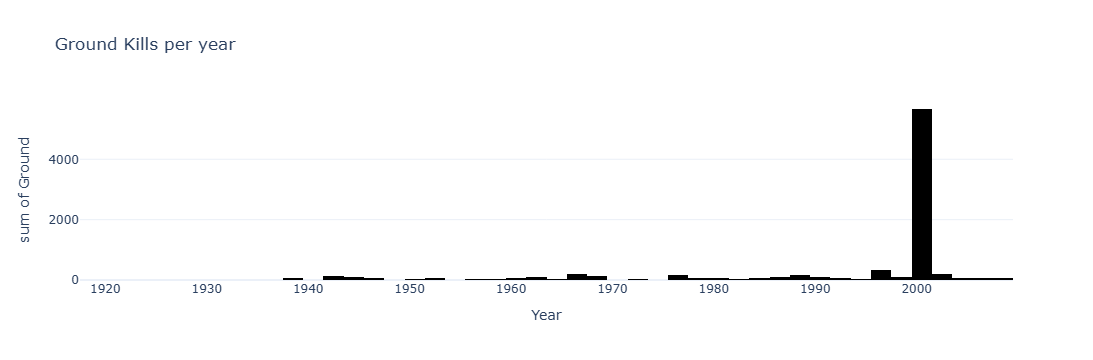

In [58]:
warnings.filterwarnings("ignore", category=DeprecationWarning)
fig = px.histogram(df,x = 'Year', y = 'Ground', template = 'plotly_white', title='Ground Kills per year',color_discrete_sequence=px.colors.sequential.gray)
fig.show()

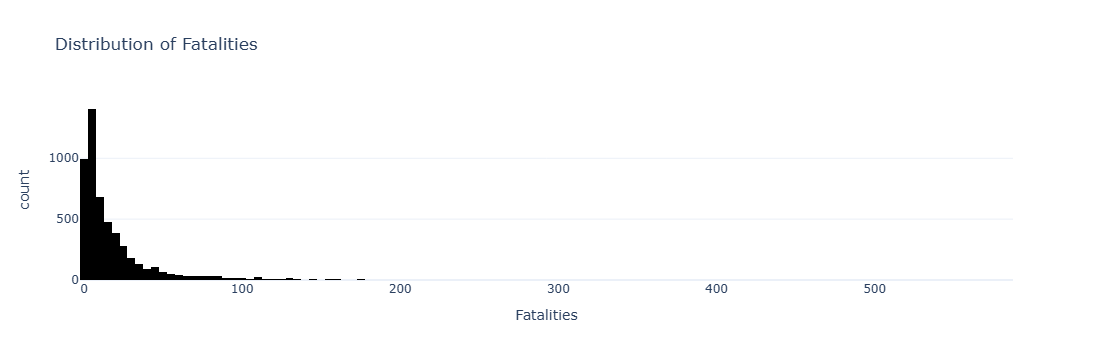

In [59]:
warnings.filterwarnings("ignore", category=DeprecationWarning)
fig1 = px.histogram(data_frame=df, x='Fatalities', title='Distribution of Fatalities', template='plotly_white',color_discrete_sequence=px.colors.sequential.gray)
fig1.show()

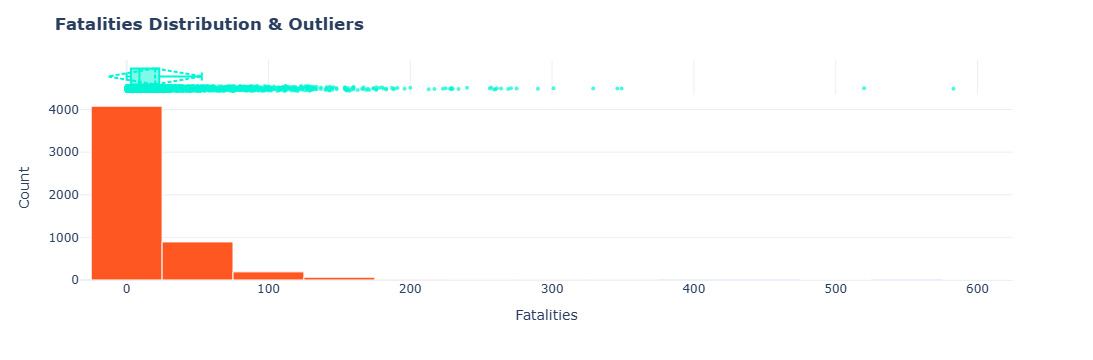

In [60]:
fig = px.histogram(
    df, 
    x="Fatalities", 
    marginal="box", 
    nbins=20, 
    hover_data=['Location'],
    template='plotly_white'
)

fig.update_traces(
    boxpoints='all',
    boxmean='sd',
    marker=dict(color='#00f5d4', size=4, opacity=0.7),
    selector=dict(type='box')
)


fig.update_traces(
    marker_color='#ff5722',
    marker_line=dict(width=1, color='#ffffff'),  
    selector=dict(type='histogram')
)

fig.update_layout(
    title='<b>Fatalities Distribution & Outliers</b>',
    xaxis_title="Fatalities",
    yaxis_title="Count",
    paper_bgcolor='rgba(0, 0, 0, 0)',
    plot_bgcolor='rgba(0, 0, 0, 0)'
)

fig.show()

This exploratory data analysis of global airline accidents illuminates key historical patterns, high-density incident locations, and fatality trends spanning over a century. The data underscores that aviation safety is an evolving dynamic—where insights derived from past tragedies directly inform future prevention. By translating these analytical findings into action, the aviation industry can continuously refine safety protocols, optimize pilot training, and drive technological innovation. Ultimately, data-driven analysis remains one of our most powerful tools for building a safer, more resilient future for global air travel.